<a href="https://colab.research.google.com/github/roshnidbth/Hybrid-Churn-Prediction-System/blob/main/Model_training_and_evaluation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🔀 Combined Multi-Domain Churn Prediction Model

Merges **Telco + E-Commerce + Bank** churn datasets into one unified model.

| Dataset | Domain | Rows | Target |
|---|---|---|---|
| Telco | Telecom | ~7,000 | `Churn` (Yes/No) |
| E-Commerce | Online Retail | ~5,600 | `Churn` (0/1) |
| Bank | Banking | ~10,000 | `Exited` (0/1) |

**Strategy**: Extract common/mappable features, add a `source` tag per dataset, then train XGBoost + Random Forest.

## Cell 1 — Install & Import Libraries

In [1]:
!pip install xgboost openpyxl --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_curve, auc, f1_score, roc_auc_score
)
from xgboost import XGBClassifier

sns.set_style('whitegrid')
print('✅ All libraries imported successfully!')

✅ All libraries imported successfully!


## Cell 2 — Upload Datasets

Upload these 3 files when prompted:
- `WA_Fn-UseC_-Telco-Customer-Churn.csv` (or your Telco CSV)
- `E_Commerce_Dataset.xlsx`
- `Churn_Modelling.csv`

In [2]:
from google.colab import files

print('Upload your 3 files:')
uploaded = files.upload()

for fname in uploaded.keys():
    print(f'  ✅ Uploaded: {fname}')

Upload your 3 files:


Saving Churn_Modelling.csv to Churn_Modelling.csv
Saving E Commerce Dataset.xlsx to E Commerce Dataset.xlsx
Saving Telco-Customer-Churn.csv to Telco-Customer-Churn.csv
  ✅ Uploaded: Churn_Modelling.csv
  ✅ Uploaded: E Commerce Dataset.xlsx
  ✅ Uploaded: Telco-Customer-Churn.csv


## Cell 3 — Load Each Dataset

In [3]:
import glob, os

# ── Auto-detect file paths ─────────────────────────────────────────
def find_file(patterns):
    for p in patterns:
        matches = glob.glob(p, recursive=True)
        if matches:
            return matches[0]
    return None

telco_path  = find_file(['/content/**/*Telco*.csv', '/content/**/*telco*.csv', '/content/**/*churn*.csv'])
ecomm_path  = find_file(['/content/**/*E_Commerce*.xlsx', '/content/**/*ecomm*.xlsx', '/content/**/*Commerce*.xlsx'])
bank_path   = find_file(['/content/**/*Churn_Modelling*.csv', '/content/**/*Modelling*.csv', '/content/**/*bank*.csv'])

print(f'Telco  : {telco_path}')
print(f'E-Comm : {ecomm_path}')
print(f'Bank   : {bank_path}')

# ── Load ──────────────────────────────────────────────────────────
df_telco = pd.read_csv(telco_path)
df_ecomm = pd.read_excel(ecomm_path, sheet_name='E Comm')
df_bank  = pd.read_csv(bank_path)

print(f'\nTelco shape  : {df_telco.shape}')
print(f'E-Comm shape : {df_ecomm.shape}')
print(f'Bank shape   : {df_bank.shape}')
print('\n✅ All datasets loaded!')

Telco  : /content/Telco-Customer-Churn.csv
E-Comm : /content/E Commerce Dataset.xlsx
Bank   : /content/Churn_Modelling.csv

Telco shape  : (7043, 21)
E-Comm shape : (5630, 20)
Bank shape   : (10000, 14)

✅ All datasets loaded!


## Cell 4 — Standardise & Extract Common Features

We extract 5 features that exist (or can be mapped) across all 3 datasets:

| Unified Feature | Telco | E-Commerce | Bank |
|---|---|---|---|
| `tenure` | `tenure` | `Tenure` | `Tenure` |
| `monthly_charges` | `MonthlyCharges` | `CashbackAmount` (proxy) | `Balance/12` (proxy) |
| `gender` | `gender` | `Gender` | `Gender` |
| `num_products` | `NumAddOnServices` (engineered) | `NumberOfDeviceRegistered` | `NumOfProducts` |
| `is_active` | contract type → active flag | `Complain` (inverse) | `IsActiveMember` |

Plus a `source` column so the model knows which domain each row came from.

In [4]:
# ══════════════════════════════════════════════════════════════════
# TELCO
# ══════════════════════════════════════════════════════════════════
df_t = df_telco.copy()

# Fix TotalCharges
df_t['TotalCharges'] = pd.to_numeric(df_t['TotalCharges'], errors='coerce')
df_t['TotalCharges'].fillna(df_t['TotalCharges'].median(), inplace=True)

# Target
df_t['churn'] = df_t['Churn'].map({'Yes': 1, 'No': 0})
df_t.dropna(subset=['churn'], inplace=True)

# Gender (M/F → 1/0)
df_t['gender_enc'] = (df_t['gender'].str.lower() == 'male').astype(int)

# Tenure (already numeric, months)
df_t['tenure_norm'] = df_t['tenure']

# Monthly charges
df_t['monthly_charges'] = df_t['MonthlyCharges']

# Number of add-on services (count of 'Yes' in service columns)
service_cols = ['PhoneService','MultipleLines','InternetService',
                'OnlineSecurity','OnlineBackup','DeviceProtection',
                'TechSupport','StreamingTV','StreamingMovies']
df_t['num_products'] = df_t[service_cols].apply(
    lambda row: (row == 'Yes').sum(), axis=1)

# Is active: not on month-to-month = more committed = active
df_t['is_active'] = (df_t['Contract'] != 'Month-to-month').astype(int)

# Source tag
df_t['source'] = 0  # 0 = Telco

telco_final = df_t[['tenure_norm','monthly_charges','gender_enc',
                     'num_products','is_active','source','churn']].copy()
telco_final.columns = ['tenure','monthly_charges','gender',
                        'num_products','is_active','source','churn']

print(f'Telco  rows: {len(telco_final)} | Churn rate: {telco_final["churn"].mean():.2%}')


# ══════════════════════════════════════════════════════════════════
# E-COMMERCE
# ══════════════════════════════════════════════════════════════════
df_e = df_ecomm.copy()

# Target
df_e['churn'] = df_e['Churn'].astype(int)

# Gender
df_e['gender_enc'] = (df_e['Gender'].str.lower() == 'male').astype(int)

# Tenure (months, has NaNs — fill with median)
df_e['Tenure'].fillna(df_e['Tenure'].median(), inplace=True)
df_e['tenure_norm'] = df_e['Tenure']

# Monthly charges proxy: CashbackAmount (fill NaN)
df_e['CashbackAmount'].fillna(df_e['CashbackAmount'].median(), inplace=True)
df_e['monthly_charges'] = df_e['CashbackAmount']

# Number of products: devices registered
df_e['num_products'] = df_e['NumberOfDeviceRegistered']

# Is active: no complaint = satisfied = active
df_e['is_active'] = (df_e['Complain'] == 0).astype(int)

# Source tag
df_e['source'] = 1  # 1 = E-Commerce

ecomm_final = df_e[['tenure_norm','monthly_charges','gender_enc',
                     'num_products','is_active','source','churn']].copy()
ecomm_final.columns = ['tenure','monthly_charges','gender',
                        'num_products','is_active','source','churn']

print(f'E-Comm rows: {len(ecomm_final)} | Churn rate: {ecomm_final["churn"].mean():.2%}')


# ══════════════════════════════════════════════════════════════════
# BANK
# ══════════════════════════════════════════════════════════════════
df_b = df_bank.copy()

# Target
df_b['churn'] = df_b['Exited'].astype(int)

# Gender
df_b['gender_enc'] = (df_b['Gender'].str.lower() == 'male').astype(int)

# Tenure (already in years — multiply by 12 to normalise to months)
df_b['tenure_norm'] = df_b['Tenure'] * 12

# Monthly charges proxy: Balance / 12
df_b['monthly_charges'] = df_b['Balance'] / 12

# Number of products
df_b['num_products'] = df_b['NumOfProducts']

# Is active member
df_b['is_active'] = df_b['IsActiveMember']

# Source tag
df_b['source'] = 2  # 2 = Bank

bank_final = df_b[['tenure_norm','monthly_charges','gender_enc',
                    'num_products','is_active','source','churn']].copy()
bank_final.columns = ['tenure','monthly_charges','gender',
                       'num_products','is_active','source','churn']

print(f'Bank   rows: {len(bank_final)} | Churn rate: {bank_final["churn"].mean():.2%}')

Telco  rows: 7043 | Churn rate: 26.54%
E-Comm rows: 5630 | Churn rate: 16.84%
Bank   rows: 10000 | Churn rate: 20.37%


## Cell 5 — Merge & Explore Combined Dataset

In [5]:
# ── Combine all three ─────────────────────────────────────────────
df_combined = pd.concat([telco_final, ecomm_final, bank_final],
                         ignore_index=True)

print('=' * 50)
print('       COMBINED DATASET SUMMARY')
print('=' * 50)
print(f'Total rows   : {len(df_combined):,}')
print(f'Total columns: {df_combined.shape[1]}')
print(f'Overall churn rate: {df_combined["churn"].mean():.2%}')
print(f'Missing values: {df_combined.isnull().sum().sum()}')
print()
print(df_combined.groupby("source")["churn"].agg(["count","mean"]).rename(
    index={0:"Telco", 1:"E-Commerce", 2:"Bank"}
).rename(columns={"count":"Rows","mean":"Churn Rate"}))
print()
df_combined.head()

       COMBINED DATASET SUMMARY
Total rows   : 22,673
Total columns: 7
Overall churn rate: 21.41%
Missing values: 0

             Rows  Churn Rate
source                       
Telco        7043    0.265370
E-Commerce   5630    0.168384
Bank        10000    0.203700



,tenure,monthly_charges,gender,num_products,is_active,source,churn
0,1.0,29.85,0,1,0,0,0
1,34.0,56.95,1,3,1,0,0
2,2.0,53.85,1,3,0,0,1
3,45.0,42.30,1,3,1,0,0
4,2.0,70.70,0,1,0,0,1


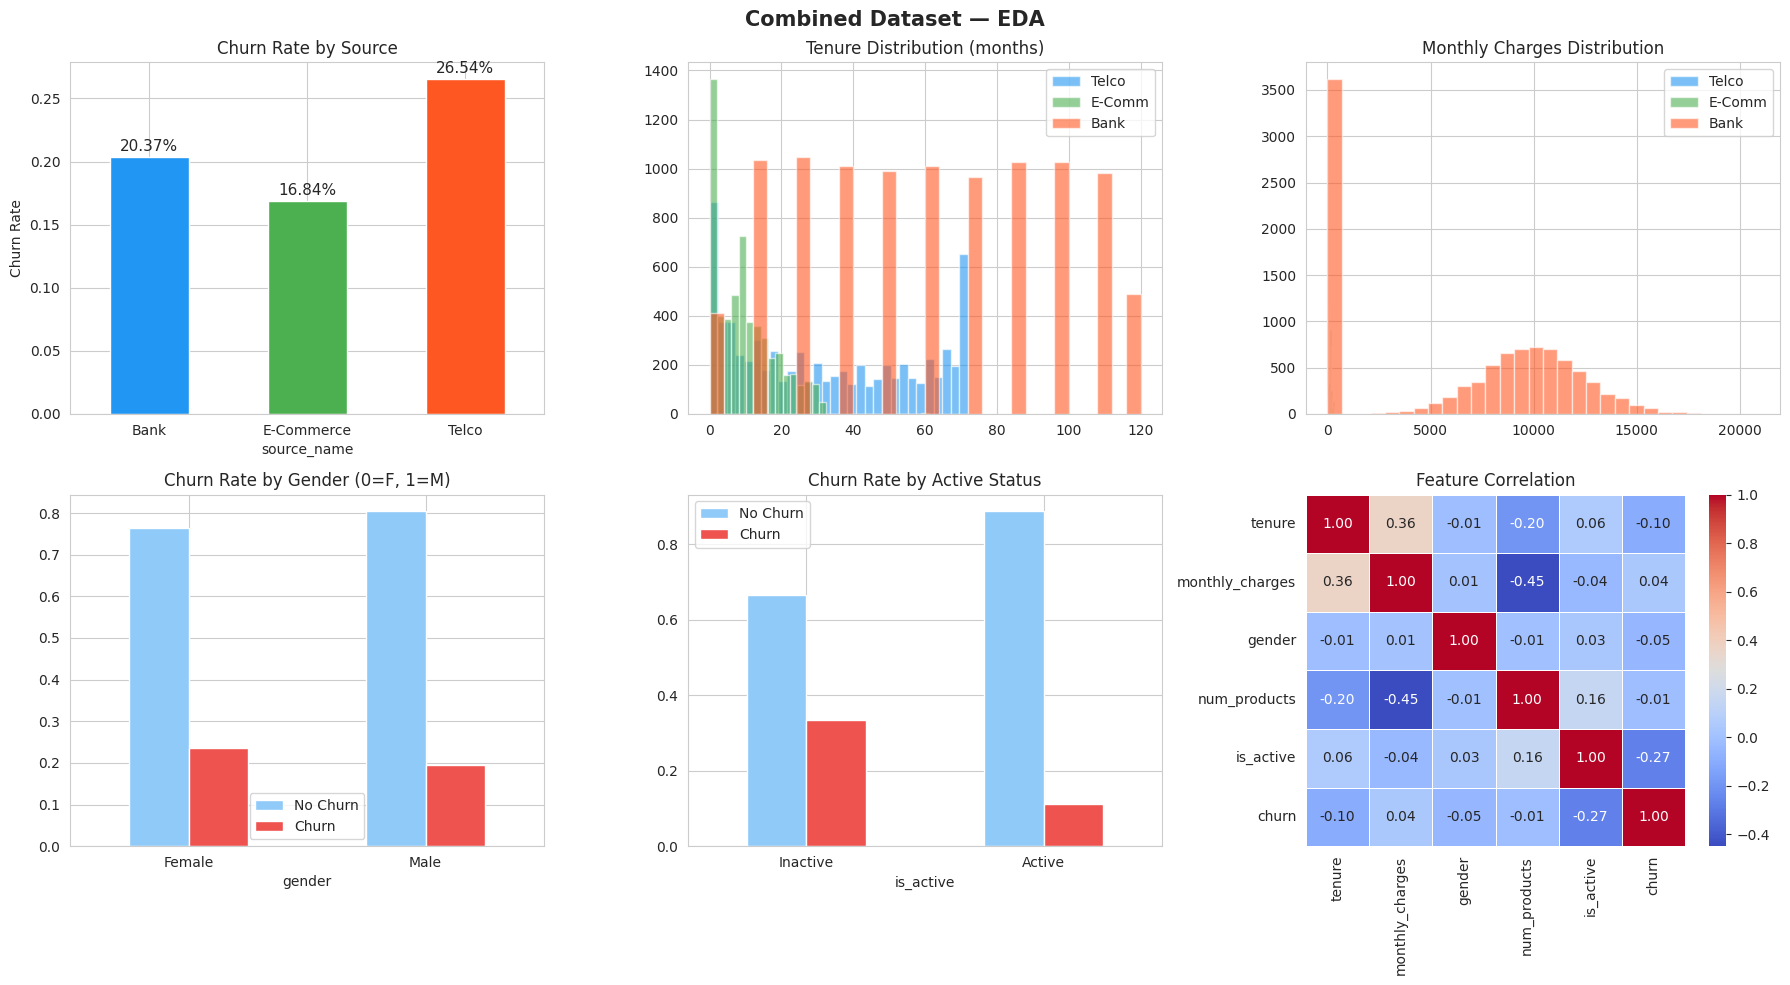

✅ EDA complete!


In [6]:
# ── EDA: Churn rate per source + feature distributions ───────────
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Combined Dataset — EDA', fontsize=15, fontweight='bold')

source_labels = {0: 'Telco', 1: 'E-Commerce', 2: 'Bank'}
df_combined['source_name'] = df_combined['source'].map(source_labels)

# Churn rate per source
churn_by_source = df_combined.groupby('source_name')['churn'].mean()
churn_by_source.plot(kind='bar', ax=axes[0,0], color=['#2196F3','#4CAF50','#FF5722'],
                     edgecolor='white', width=0.5)
axes[0,0].set_title('Churn Rate by Source', fontsize=12)
axes[0,0].set_ylabel('Churn Rate')
axes[0,0].set_xticklabels(churn_by_source.index, rotation=0)
for p in axes[0,0].patches:
    axes[0,0].annotate(f'{p.get_height():.2%}',
        (p.get_x() + p.get_width()/2, p.get_height() + 0.005),
        ha='center', fontsize=11)

# Tenure distribution
for src, col, lbl in [(0,'#2196F3','Telco'),(1,'#4CAF50','E-Comm'),(2,'#FF5722','Bank')]:
    axes[0,1].hist(df_combined[df_combined['source']==src]['tenure'],
                   bins=30, alpha=0.6, color=col, label=lbl)
axes[0,1].set_title('Tenure Distribution (months)', fontsize=12)
axes[0,1].legend()

# Monthly charges
for src, col, lbl in [(0,'#2196F3','Telco'),(1,'#4CAF50','E-Comm'),(2,'#FF5722','Bank')]:
    axes[0,2].hist(df_combined[df_combined['source']==src]['monthly_charges'],
                   bins=30, alpha=0.6, color=col, label=lbl)
axes[0,2].set_title('Monthly Charges Distribution', fontsize=12)
axes[0,2].legend()

# Churn by gender
pd.crosstab(df_combined['gender'], df_combined['churn'], normalize='index').plot(
    kind='bar', ax=axes[1,0], color=['#90CAF9','#EF5350'], edgecolor='white', width=0.5)
axes[1,0].set_title('Churn Rate by Gender (0=F, 1=M)', fontsize=12)
axes[1,0].set_xticklabels(['Female','Male'], rotation=0)
axes[1,0].legend(['No Churn','Churn'])

# Churn by is_active
pd.crosstab(df_combined['is_active'], df_combined['churn'], normalize='index').plot(
    kind='bar', ax=axes[1,1], color=['#90CAF9','#EF5350'], edgecolor='white', width=0.5)
axes[1,1].set_title('Churn Rate by Active Status', fontsize=12)
axes[1,1].set_xticklabels(['Inactive','Active'], rotation=0)
axes[1,1].legend(['No Churn','Churn'])

# Correlation heatmap
corr = df_combined[['tenure','monthly_charges','gender','num_products','is_active','churn']].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', ax=axes[1,2],
            linewidths=0.5, annot_kws={'size':10})
axes[1,2].set_title('Feature Correlation', fontsize=12)

plt.tight_layout()
plt.savefig('combined_eda.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ EDA complete!')

## Cell 6 — Prepare Features & Split Data

In [7]:
FEATURES = ['tenure','monthly_charges','gender','num_products','is_active','source']
TARGET   = 'churn'

X = df_combined[FEATURES].values
y = df_combined[TARGET].values

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Stratified split (preserves churn ratio)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Train size : {len(X_train):,} rows')
print(f'Test size  : {len(X_test):,}  rows')
print(f'Train churn rate: {y_train.mean():.2%}')
print(f'Test  churn rate: {y_test.mean():.2%}')
print('✅ Data ready!')

Train size : 18,138 rows
Test size  : 4,535  rows
Train churn rate: 21.41%
Test  churn rate: 21.41%
✅ Data ready!


## Cell 7 — Train Models (Logistic Regression, Random Forest, XGBoost)

In [8]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest'      : RandomForestClassifier(n_estimators=200, max_depth=10,
                                                   random_state=42, n_jobs=-1),
    'XGBoost'            : XGBClassifier(n_estimators=300, learning_rate=0.05,
                                          max_depth=5, use_label_encoder=False,
                                          eval_metric='logloss', random_state=42,
                                          n_jobs=-1),
}

results = {}

for name, model in models.items():
    print(f'Training {name}...', end=' ')
    model.fit(X_train, y_train)
    y_pred  = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    results[name] = {
        'model'    : model,
        'y_pred'   : y_pred,
        'y_proba'  : y_proba,
        'accuracy' : accuracy_score(y_test, y_pred),
        'f1'       : f1_score(y_test, y_pred),
        'roc_auc'  : auc(fpr, tpr),
        'fpr'      : fpr,
        'tpr'      : tpr,
    }
    print(f'done. F1={results[name]["f1"]:.4f} | AUC={results[name]["roc_auc"]:.4f}')

# Pick best by F1
best_name = max(results, key=lambda n: (results[n]['f1'], results[n]['accuracy']))
print(f'\n🏆 Best model: {best_name}')

Training Logistic Regression... done. F1=0.0161 | AUC=0.7264
Training Random Forest... done. F1=0.4844 | AUC=0.8391
Training XGBoost... done. F1=0.4990 | AUC=0.8369

🏆 Best model: XGBoost


## Cell 8 — Results & Visualisation

In [9]:
print('\n' + '=' * 58)
print('      COMBINED MODEL COMPARISON SUMMARY')
print('=' * 58)
print(f'{"Model":<22} {"Accuracy":>10} {"F1 Score":>10} {"ROC AUC":>10}')
print('-' * 58)
for name, r in results.items():
    marker = ' ◄ BEST' if name == best_name else ''
    print(f'{name:<22} {r["accuracy"]:>10.4f} {r["f1"]:>10.4f} {r["roc_auc"]:>10.4f}{marker}')
print('=' * 58)


      COMBINED MODEL COMPARISON SUMMARY
Model                    Accuracy   F1 Score    ROC AUC
----------------------------------------------------------
Logistic Regression        0.7841     0.0161     0.7264
Random Forest              0.8291     0.4844     0.8391
XGBoost                    0.8282     0.4990     0.8369 ◄ BEST


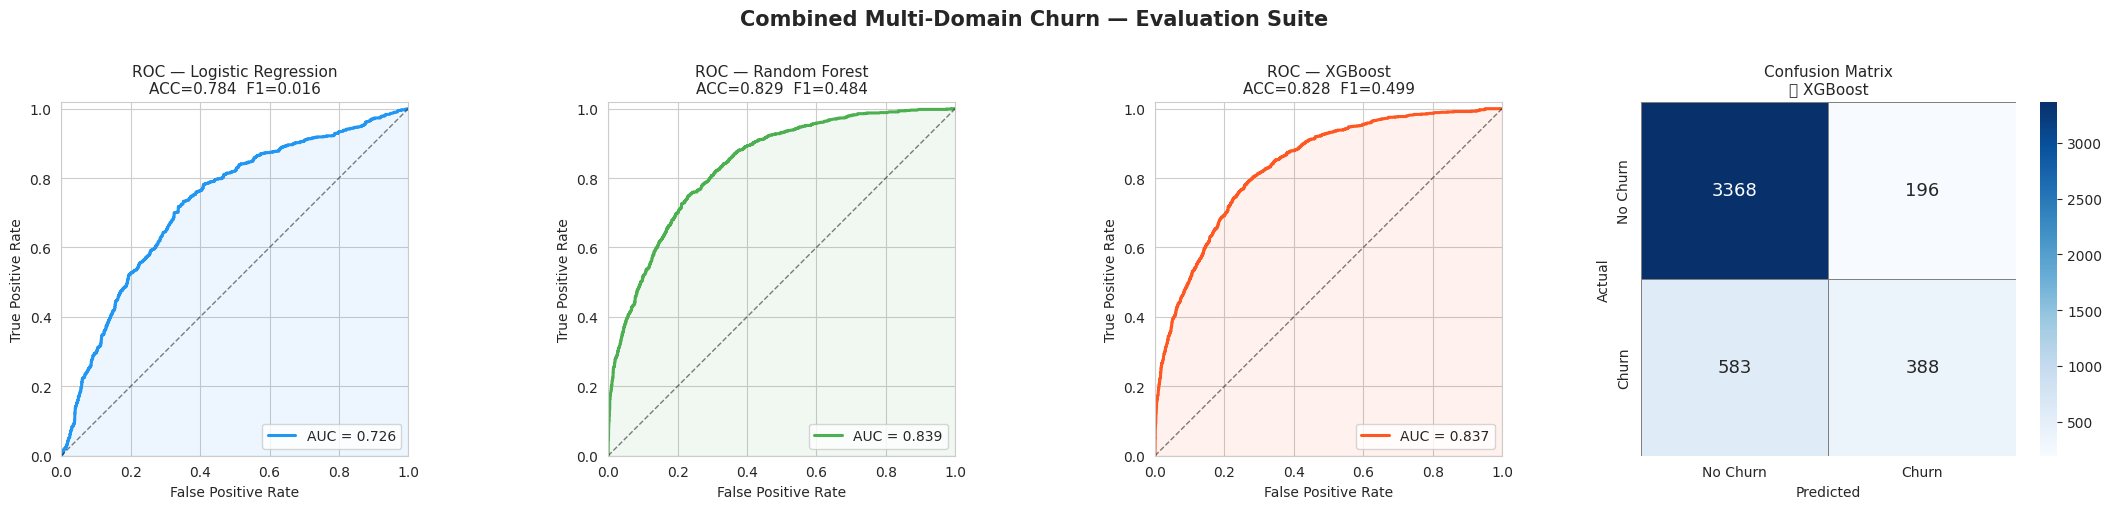

✅ Visualisation complete!


In [10]:
palette = {
    'Logistic Regression': '#2196F3',
    'Random Forest'      : '#4CAF50',
    'XGBoost'            : '#FF5722',
}

fig, axes = plt.subplots(1, 4, figsize=(22, 5))
fig.suptitle('Combined Multi-Domain Churn — Evaluation Suite',
             fontsize=15, fontweight='bold', y=1.01)

for i, (name, r) in enumerate(results.items()):
    ax = axes[i]
    ax.plot(r['fpr'], r['tpr'], color=palette[name], lw=2.2,
            label=f'AUC = {r["roc_auc"]:.3f}')
    ax.plot([0,1],[0,1],'k--', lw=1, alpha=0.5)
    ax.fill_between(r['fpr'], r['tpr'], alpha=0.08, color=palette[name])
    ax.set_xlim([0,1]); ax.set_ylim([0,1.02])
    ax.set_xlabel('False Positive Rate', fontsize=10)
    ax.set_ylabel('True Positive Rate', fontsize=10)
    ax.set_title(f'ROC — {name}\nACC={r["accuracy"]:.3f}  F1={r["f1"]:.3f}', fontsize=11)
    ax.legend(loc='lower right', fontsize=10)
    ax.set_aspect('equal')

# Confusion matrix for best
cm = confusion_matrix(y_test, results[best_name]['y_pred'])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[3],
            linewidths=0.5, linecolor='grey',
            xticklabels=['No Churn','Churn'],
            yticklabels=['No Churn','Churn'],
            annot_kws={'size': 13})
axes[3].set_title(f'Confusion Matrix\n🏆 {best_name}', fontsize=11)
axes[3].set_xlabel('Predicted', fontsize=10)
axes[3].set_ylabel('Actual', fontsize=10)

plt.tight_layout()
plt.savefig('combined_evaluation_suite.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Visualisation complete!')

## Cell 9 — Feature Importance (XGBoost & Random Forest)

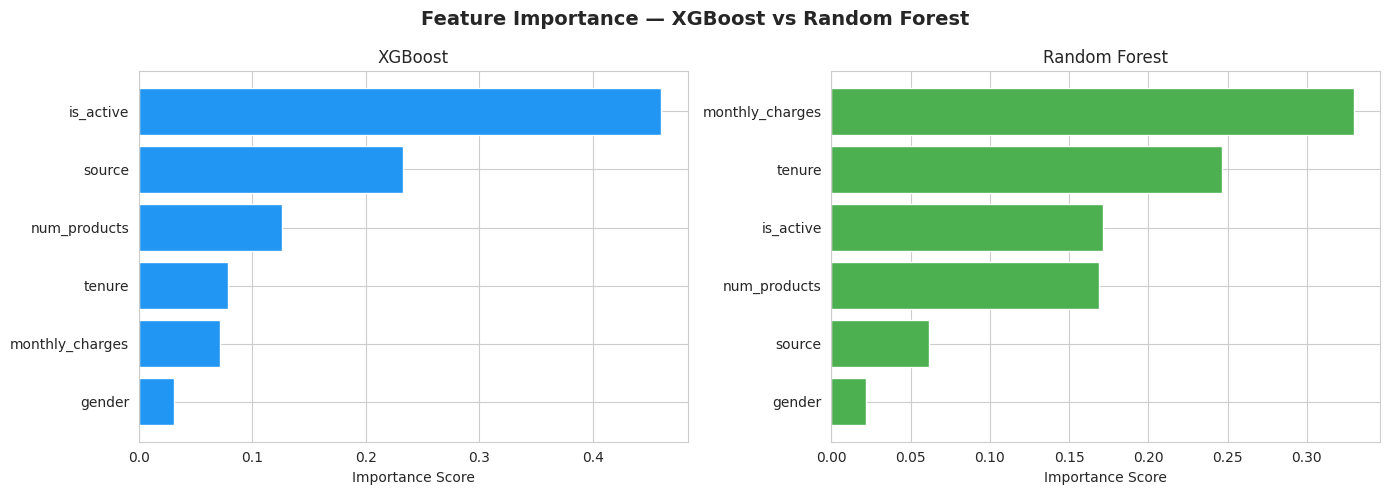

In [11]:
feature_names = FEATURES

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Feature Importance — XGBoost vs Random Forest',
             fontsize=14, fontweight='bold')

for ax, name in zip(axes, ['XGBoost', 'Random Forest']):
    model = results[name]['model']
    importances = model.feature_importances_
    sorted_idx  = np.argsort(importances)
    ax.barh([feature_names[i] for i in sorted_idx],
            importances[sorted_idx],
            color='#2196F3' if name == 'XGBoost' else '#4CAF50',
            edgecolor='white')
    ax.set_title(name, fontsize=12)
    ax.set_xlabel('Importance Score')

plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

## Cell 10 — Cross-Validation (Best Model)

In [12]:
print(f'Running 5-fold cross-validation on: {best_name}\n')

best_model = results[best_name]['model']

# Re-fit on original (unscaled) data using pipeline for clean CV
best_cv_model = type(best_model)(**best_model.get_params())

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_f1  = cross_val_score(best_cv_model, X_scaled, y, cv=cv, scoring='f1',       n_jobs=-1)
cv_auc = cross_val_score(best_cv_model, X_scaled, y, cv=cv, scoring='roc_auc',  n_jobs=-1)
cv_acc = cross_val_score(best_cv_model, X_scaled, y, cv=cv, scoring='accuracy', n_jobs=-1)

print('=' * 48)
print(f'  5-Fold CV Results — {best_name}')
print('=' * 48)
print(f'  Accuracy : {cv_acc.mean():.4f} ± {cv_acc.std():.4f}')
print(f'  F1 Score : {cv_f1.mean():.4f}  ± {cv_f1.std():.4f}')
print(f'  ROC AUC  : {cv_auc.mean():.4f} ± {cv_auc.std():.4f}')
print('=' * 48)
print('\n✅ Full combined pipeline complete!')

Running 5-fold cross-validation on: XGBoost

  5-Fold CV Results — XGBoost
  Accuracy : 0.8262 ± 0.0036
  F1 Score : 0.4773  ± 0.0184
  ROC AUC  : 0.8316 ± 0.0033

✅ Full combined pipeline complete!


## Cell 11 — Save Best Model

In [13]:
import pickle

# Save model + scaler together
artifact = {
    'model'        : results[best_name]['model'],
    'scaler'       : scaler,
    'features'     : FEATURES,
    'best_model'   : best_name,
    'source_map'   : {0: 'Telco', 1: 'E-Commerce', 2: 'Bank'},
}

with open('combined_churn_model.pkl', 'wb') as f:
    pickle.dump(artifact, f)

print(f'✅ Model saved as combined_churn_model.pkl')
print(f'   Best model : {best_name}')
print(f'   Features   : {FEATURES}')

# Download the model file
from google.colab import files
files.download('combined_churn_model.pkl')

✅ Model saved as combined_churn_model.pkl
   Best model : XGBoost
   Features   : ['tenure', 'monthly_charges', 'gender', 'num_products', 'is_active', 'source']


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>